# TN2 — Đề xuất quy trình xây dựng tập đánh giá cho kiểm tra tuân thủ GRI


In [2]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EXP_DIR = Path.cwd()
if str(EXP_DIR) not in sys.path:
    sys.path.insert(0, str(EXP_DIR))
import nli_lib as lib

for d in (lib.OUT_DIR, lib.TABLES_DIR, lib.STATS_DIR, lib.FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

REQUIRED = [
    lib.adjudicated_csv("v1"),
    lib.adjudicated_csv("v2"),
    lib.adjudicated_csv("v3"),
    lib.HUMAN_REVIEW_DONE_CSV,
    lib.DISAGREEMENTS_CSV,
    lib.PAIRING_CSV,
    lib.PRE_FIX_PAIRING_CSV,
    lib.HUMAN_REVIEW_V2_CSV,
    lib.DATA_DIR / "04_human_T3_GTv2_150" / "human_review_v2_retest.csv",
    lib.DATA_DIR / "04_human_T3_GTv2_150" / "human_review_v2_agreement.csv",
    lib.DATA_DIR / "04_human_T3_GTv2_150" / "sample_agreement.csv",
]
missing = [str(f) for f in REQUIRED if not f.exists()]
if missing:
    raise FileNotFoundError(f"Missing inputs: {missing}")
print("[OK] All required inputs present")


[OK] All required inputs present


## Tầng 1 — κ panel

In [3]:
human  = pd.read_csv(lib.HUMAN_REVIEW_DONE_CSV,   low_memory=False)
adj_v1 = pd.read_csv(lib.adjudicated_csv("v1"),   low_memory=False)
adj_v2 = pd.read_csv(lib.adjudicated_csv("v2"),   low_memory=False)
adj_v3 = pd.read_csv(lib.adjudicated_csv("v3"),   low_memory=False)

print(f"human review:     {human.shape}  (n_human={len(human)})")
print(f"adjudicated v1:   {adj_v1.shape}  (n_disagreement={len(adj_v1)})")
print(f"adjudicated v2:   {adj_v2.shape}")
print(f"adjudicated v3:   {adj_v3.shape}  non-null verdicts: {adj_v3['correct_status'].notna().sum()}")

print("\nHuman marginals (n=120):")
h_marg = human["human_correct_status"].str.strip().str.lower().value_counts()
for s in ["pass", "partial", "no_evidence"]:
    n = int(h_marg.get(s, 0))
    print(f"  {s:14s} {n:3d}  ({n/len(human)*100:.1f}%)")


human review:     (120, 12)  (n_human=120)
adjudicated v1:   (2361, 19)  (n_disagreement=2361)
adjudicated v2:   (2361, 19)
adjudicated v3:   (2361, 19)  non-null verdicts: 2361

Human marginals (n=120):
  pass            38  (31.7%)
  partial         48  (40.0%)
  no_evidence     34  (28.3%)


In [4]:
kappa_panel = lib.arbiter_kappa_panel(human, adj_v1, adj_v2, adj_v3)
print("Cohen's κ panel:")
print(kappa_panel.to_string(index=False))

kappa_panel.to_csv(lib.TABLES_DIR / "T_TN4_kappa_panel.csv", index=False)
print(f"\nSaved: {lib.TABLES_DIR / 'T_TN4_kappa_panel.csv'}")

k_v1 = float(kappa_panel.loc[kappa_panel["arbiter"] == "v1", "cohen_kappa"].iloc[0])
k_v2 = float(kappa_panel.loc[kappa_panel["arbiter"] == "v2", "cohen_kappa"].iloc[0])
k_v3 = float(kappa_panel.loc[kappa_panel["arbiter"] == "v3", "cohen_kappa"].iloc[0])
print(f"\nΔκ (v2 - v1) = {k_v2 - k_v1:+.4f}  (v2 anti-hedge improves over v1 under-specified)")
print(f"Δκ (v3 - v2) = {k_v3 - k_v2:+.4f}  (v3 broad-partial regresses vs v2 DECISIVENESS)")


Cohen's κ panel:
arbiter   n  agreement_rate  cohen_kappa interpretation
     v1 120          0.5500       0.2892           fair
     v2 120          0.5917       0.4108       moderate
     v3 120          0.5500       0.2833           fair

Saved: d:\Final_GRAG\experiments\module3_nli\outputs\tables\T_TN4_kappa_panel.csv

Δκ (v2 - v1) = +0.1216  (v2 anti-hedge improves over v1 under-specified)
Δκ (v3 - v2) = -0.1275  (v3 broad-partial regresses vs v2 DECISIVENESS)


Marginal status distribution (Hình fig:c4-arbiter-marginal):
    source   n  n_pass  n_partial  n_no_evidence  pct_pass  pct_partial  pct_no_evidence
     Human 120      38         48             34      31.7         40.0             28.3
Arbiter v1 120      14         82             24      11.7         68.3             20.0
Arbiter v2 120      50         10             60      41.7          8.3             50.0
Arbiter v3 120      15         87             18      12.5         72.5             15.0

Saved: d:\Final_GRAG\experiments\module3_nli\outputs\tables\T_TN4_marginal_distribution.csv


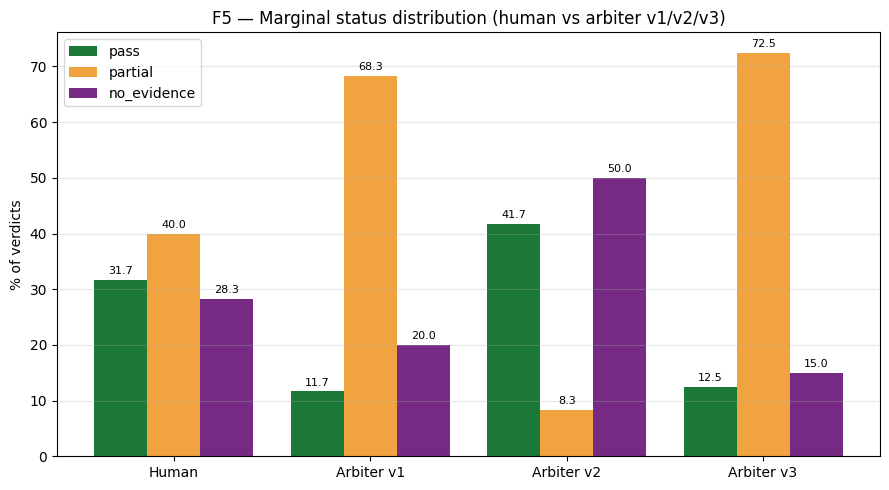

Saved: d:\Final_GRAG\experiments\module3_nli\outputs\figures\F5_arbiter_marginal.png


In [5]:
marg = lib.arbiter_marginal_distribution(human, adj_v1, adj_v2, adj_v3)
print("Marginal status distribution (Hình fig:c4-arbiter-marginal):")
print(marg.to_string(index=False))

marg.to_csv(lib.TABLES_DIR / "T_TN4_marginal_distribution.csv", index=False)
print(f"\nSaved: {lib.TABLES_DIR / 'T_TN4_marginal_distribution.csv'}")

fig, ax = plt.subplots(figsize=(9, 5))
sources = marg["source"].tolist()
x = np.arange(len(sources))
width = 0.27
ax.bar(x - width, marg["pct_pass"].values,        width, label="pass",        color="#1b7837")
ax.bar(x,         marg["pct_partial"].values,     width, label="partial",     color="#f1a340")
ax.bar(x + width, marg["pct_no_evidence"].values, width, label="no_evidence", color="#762a83")
ax.set_xticks(x); ax.set_xticklabels(sources)
ax.set_ylabel("% of verdicts")
ax.set_title("F5 — Marginal status distribution (human vs arbiter v1/v2/v3)")
ax.legend(); ax.grid(axis="y", alpha=0.3)
for i, (pp, pa, pn) in enumerate(zip(marg["pct_pass"].values, marg["pct_partial"].values, marg["pct_no_evidence"].values)):
    ax.text(i - width, pp + 1, f"{pp:.1f}", ha="center", fontsize=8)
    ax.text(i,         pa + 1, f"{pa:.1f}", ha="center", fontsize=8)
    ax.text(i + width, pn + 1, f"{pn:.1f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(lib.FIGURES_DIR / "F5_arbiter_marginal.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {lib.FIGURES_DIR / 'F5_arbiter_marginal.png'}")


In [6]:
r3 = lib.arbiter_vs_human_kappa(human, adj_v3, arbiter_label="v3")
print("v3 vs human (broad-partial design):")
print(f"  n              : {r3['n']}")
print(f"  agreement_rate : {r3['agreement_rate']:.4f}")
print(f"  cohen κ        : {r3['cohen_kappa']:.4f}  ({lib._interpret_kappa(r3['cohen_kappa'])})")
print("\nConfusion matrix v3 (rows=v3, cols=human):")
print(r3["confusion_matrix"].to_string())

with (lib.STATS_DIR / "TN4_v3_failed.json").open("w", encoding="utf-8") as f:
    json.dump(
        {
            "n": r3["n"],
            "agreement_rate": r3["agreement_rate"],
            "cohen_kappa": r3["cohen_kappa"],
            "arbiter_marginals": r3["arbiter_marginals"],
        },
        f, indent=2, ensure_ascii=False,
    )
print(f"\nSaved: {lib.STATS_DIR / 'TN4_v3_failed.json'}")


v3 vs human (broad-partial design):
  n              : 120
  agreement_rate : 0.5500
  cohen κ        : 0.2833  (fair)

Confusion matrix v3 (rows=v3, cols=human):
             pass  partial  no_evidence
pass           12        1            2
partial        25       42           20
no_evidence     1        5           12

Saved: d:\Final_GRAG\experiments\module3_nli\outputs\stats\TN4_v3_failed.json


## Tầng 2 — sign reversal E1


In [7]:
pairing_post = pd.read_csv(lib.PAIRING_CSV, low_memory=False)
print(f"Post-fix pairing: {pairing_post.shape}")

sr = lib.sign_reversal_e1(pairing_post, adj_v1, adj_v2)
print(f"\nSign reversal analysis (HINT main = V_new vs A0, post-fix universe):")
print(f"  n_disagreement_cases : {sr['n_disagreements']}")
print(f"  E1 under v1 GT       : {sr['e1_v1_pp']:+.2f} pp")
print(f"  E1 under v2 GT       : {sr['e1_v2_pp']:+.2f} pp")
print(f"  Δ (v2 - v1)          : {sr['e1_v2_pp'] - sr['e1_v1_pp']:+.2f} pp")
print(f"  sign reversed?       : {sr['sign_reversed']}")

with (lib.STATS_DIR / "TN4_sign_reversal.json").open("w", encoding="utf-8") as f:
    json.dump(sr, f, indent=2)
print(f"\nSaved: {lib.STATS_DIR / 'TN4_sign_reversal.json'}")


Post-fix pairing: (8670, 39)

Sign reversal analysis (HINT main = V_new vs A0, post-fix universe):
  n_disagreement_cases : 2361
  E1 under v1 GT       : -6.31 pp
  E1 under v2 GT       : +3.64 pp
  Δ (v2 - v1)          : +9.95 pp
  sign reversed?       : True

Saved: d:\Final_GRAG\experiments\module3_nli\outputs\stats\TN4_sign_reversal.json


## Tầng 3 — GT v2 reliability + bug logic

1. **Test-retest κ** : 20 case 
2. **Random-check κ** : 30 case đồng thuận

In [8]:
GTV2_DIR = lib.DATA_DIR / "04_human_T3_GTv2_150"
gtv2_main      = pd.read_csv(GTV2_DIR / "human_review_v2.csv")
gtv2_retest    = pd.read_csv(GTV2_DIR / "human_review_v2_retest.csv")
gtv2_agreement = pd.read_csv(GTV2_DIR / "human_review_v2_agreement.csv")
samp_agreement = pd.read_csv(GTV2_DIR / "sample_agreement.csv")

retest_join = (
    gtv2_main[["case_id", "human_correct_status"]].rename(columns={"human_correct_status": "main"})
    .merge(
        gtv2_retest[["case_id", "human_correct_status"]].rename(columns={"human_correct_status": "retest"}),
        on="case_id", how="inner",
    )
)
kappa_retest = float(lib.cohen_kappa(retest_join["main"], retest_join["retest"], labels=lib.STATUS_LABELS))
print(f"[Test-retest]  n={len(retest_join)}  κ = {kappa_retest:.4f}  ({lib._interpret_kappa(kappa_retest)})")

agree_join = gtv2_agreement[["case_id", "human_correct_status"]].merge(
    samp_agreement[["case_id", "a0_status_resolved"]], on="case_id", how="inner",
)
kappa_random = float(lib.cohen_kappa(agree_join["human_correct_status"], agree_join["a0_status_resolved"], labels=lib.STATUS_LABELS))
print(f"[Random-check] n={len(agree_join)}  κ = {kappa_random:.4f}  ({lib._interpret_kappa(kappa_random)})")

gtv2_reliability = {
    "test_retest": {"n": int(len(retest_join)), "cohen_kappa": kappa_retest, "interpretation": lib._interpret_kappa(kappa_retest)},
    "random_check": {"n": int(len(agree_join)), "cohen_kappa": kappa_random, "interpretation": lib._interpret_kappa(kappa_random), "reference": "a0_status_resolved (pipeline consensus baseline)"},
}
out = lib.STATS_DIR / "gtv2_reliability.json"
out.write_text(json.dumps(gtv2_reliability, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"\nSaved: {out}")


[Test-retest]  n=20  κ = 0.7628  (substantial)
[Random-check] n=30  κ = 0.7110  (substantial)

Saved: d:\Final_GRAG\experiments\module3_nli\outputs\stats\gtv2_reliability.json
